
# Experiment 9: 3D APF Obstacle Avoidance

This notebook contains a clean 3D Artificial Potential Field (APF) implementation and one simple 3D example using the same style of demo path used in the DMP notebooks, so the performance can be compared directly.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

def attractive_force(pos, goal, k_att=1.0):
    pos = np.asarray(pos, dtype=float).reshape(-1,)
    goal = np.asarray(goal, dtype=float).reshape(-1,)
    return k_att * (goal - pos)


def repulsive_force(pos, obstacle, k_rep=1.0, d0=1.0, eps=1e-12):
    pos = np.asarray(pos, dtype=float).reshape(-1,)
    obstacle = np.asarray(obstacle, dtype=float).reshape(-1,)

    diff = pos-obstacle
    d = np.linalg.norm(diff) + eps

    if d > d0:
        return np.zeros_like(pos)

    return k_rep * (1.0/d - 1.0/d0) * diff/(d**3)


def total_force(pos, goal, obstacles=None, k_att=1.0, k_rep=1.0, d0=1.0, eps=1e-12):
    F = attractive_force(pos, goal, k_att=k_att)

    if obstacles is not None:
        obs = np.asarray(obstacles, dtype=float)
        if obs.ndim == 1:
            obs = obs.reshape(1,-1)
        for o in obs:
            F += repulsive_force(pos, o, k_rep=k_rep, d0=d0, eps=eps)

    return F


def apf_path(start, goal, obstacles=None,k_att=1.0, k_rep=0.08, d0=0.5,
             dt=0.02, max_steps=3000, tol=1e-2, vmax=None): # computes the path from start to goal using APF method 1
    start = np.asarray(start, dtype=float).reshape(-1,)
    goal  = np.asarray(goal, dtype=float).reshape(-1,)

    q = start.copy()
    path = [q.copy()]

    for _ in range(max_steps):
        F = total_force(q, goal, obstacles, k_att=k_att, k_rep=k_rep, d0=d0)

        if vmax is not None:
            nF = np.linalg.norm(F) # computes the normalized force vector
            if nF > vmax:
                F = (vmax / (nF+1e-12)) * F

        q = q + dt*F # updates the position based on the total force and time step
        path.append(q.copy()) # adds the new position to the path

        if np.linalg.norm(q - goal) < tol:
            break

    return np.vstack(path)


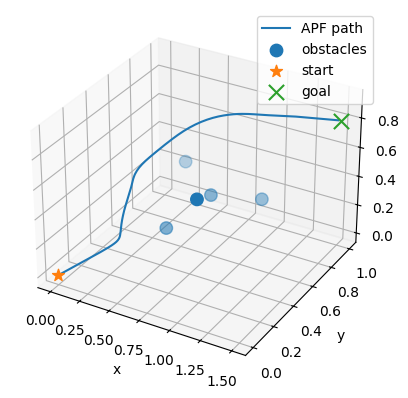

In [2]:
import numpy as np
import matplotlib.pyplot as plt

start = np.array([0.0, 0.0, 0.0])
goal  = np.array([1.5, 1.0, 0.8])

obstacles = np.array([
    [0.6, 0.35, 0.25],
    [0.8, 0.55, 0.40],
    [0.5, 0.65, 0.50],
    [0.9, 0.30, 0.55],
    [1.1, 0.70, 0.35],
])

path = apf_path(
    start, goal, obstacles,
    k_att=1.0, k_rep=0.10, d0=0.55,
    dt=0.02, tol=2e-2, vmax=2.0, max_steps=6000
)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot(path[:,0], path[:,1], path[:,2], label="APF path")
ax.scatter(obstacles[:,0], obstacles[:,1], obstacles[:,2], marker="o", s=80, label="obstacles")
ax.scatter(start[0], start[1], start[2], marker="*", s=80, label="start")
ax.scatter(goal[0], goal[1], goal[2], marker="x", s=120, label="goal")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.legend()
plt.show()


In [3]:
# Final goal error
final_goal_error = np.linalg.norm(path[-1] - goal)

# Minimum obstacle distance
distances = np.linalg.norm(path[:, None, :] - obstacles[None, :, :], axis=2)

# Minimum distance to each obstacle and overall minimum distance
min_distance_each_obstacle = np.min(distances, axis=0)
min_distance_overall = np.min(distances)

path_length = np.sum(np.linalg.norm(np.diff(path, axis=0), axis=1))

print("final_goal_error:", final_goal_error)
print("min_distance_each_obstacle:", min_distance_each_obstacle)
print("min_distance_overall:", min_distance_overall)
print("path_length:", path_length)

final_goal_error: 0.019645527255919556
min_distance_each_obstacle: [0.31202924 0.48738976 0.34695932 0.41046124 0.53687851]
min_distance_overall: 0.3120292446677408
path_length: 2.32589014874369
